<a href="https://colab.research.google.com/github/EMANFATIMA06/DATA-SCIENCE-AND-ANALYTICS-/blob/main/Energy%20Consumption%20Time%20Series%20Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Energy Consumption Time Series Forecasting***

In [18]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [19]:
df = pd.read_csv("/content/household_power_consumption - Copy.csv")

 1- The raw file only has a "time" (HH:MM:SS) column with no date, and the

 2- rows are minute-level readings that repeat every 1440 rows (1 day).

 3- We reconstruct a continuous datetime index by assigning sequential

 4- synthetic dates, starting from an arbitrary reference date.

In [20]:
n_per_day = 1440
n_days = int(np.ceil(len(df) / n_per_day))
start_date = pd.Timestamp("2023-01-01")

day_index = np.arange(len(df)) // n_per_day
date_list = pd.date_range(start_date, periods=n_days, freq="D")
row_dates = date_list[day_index]

df["time"] = df["time"].astype(str).str.strip()
df["datetime"] = pd.to_datetime(row_dates.astype(str)) + pd.to_timedelta(df["time"], errors="coerce")
df = df.dropna(subset=["datetime"])

df.drop(columns=["time"], inplace=True)
df.set_index("datetime", inplace=True)

print("Data range:", df.index.min(), "to", df.index.max())
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

Data range: 2023-01-01 00:00:00 to 2023-06-30 23:59:00
Shape: (260640, 7)
Missing values:
 global_active_power      3771
global_reactive_power    3771
voltage                  3771
global_intensity         3771
sub_metering_1           3771
sub_metering_2           3771
sub_metering_3           3771
dtype: int64


In [21]:
# Handle missing readings (small gaps) via forward/backward fill
df = df.sort_index()
df = df.ffill().bfill()

In [22]:
# 2. RESAMPLE TO HOURLY FREQUENCY
hourly = df["global_active_power"].resample("h").mean().to_frame()
hourly.rename(columns={"global_active_power": "power"}, inplace=True)
hourly = hourly.ffill()

print("\nHourly resampled shape:", hourly.shape)
print(hourly.head())


Hourly resampled shape: (4344, 1)
                        power
datetime                     
2023-01-01 00:00:00  2.550633
2023-01-01 01:00:00  2.523400
2023-01-01 02:00:00  2.582333
2023-01-01 03:00:00  2.541667
2023-01-01 04:00:00  2.475733


In [23]:
# 3. TIME-BASED FEATURE ENGINEERING
hourly["hour"] = hourly.index.hour
hourly["day_of_week"] = hourly.index.dayofweek           # 0=Mon ... 6=Sun
hourly["is_weekend"] = (hourly["day_of_week"] >= 5).astype(int)
hourly["month"] = hourly.index.month
hourly["day"] = hourly.index.day


In [24]:
# Lag features (useful for XGBoost)
hourly["lag_1"] = hourly["power"].shift(1)
hourly["lag_24"] = hourly["power"].shift(24)     # same hour, previous day
hourly["lag_168"] = hourly["power"].shift(168)   # same hour, previous week
hourly["rolling_mean_24"] = hourly["power"].shift(1).rolling(24).mean()


In [25]:
hourly.dropna(inplace=True)
print("\nFeature-engineered data sample:\n", hourly.head())


Feature-engineered data sample:
                         power  hour  day_of_week  is_weekend  month  day  \
datetime                                                                   
2023-01-08 00:00:00  1.360467     0            6           1      1    8   
2023-01-08 01:00:00  1.350667     1            6           1      1    8   
2023-01-08 02:00:00  1.384833     2            6           1      1    8   
2023-01-08 03:00:00  1.356900     3            6           1      1    8   
2023-01-08 04:00:00  1.375900     4            6           1      1    8   

                        lag_1    lag_24   lag_168  rolling_mean_24  
datetime                                                            
2023-01-08 00:00:00  1.463867  0.903200  2.550633         1.699736  
2023-01-08 01:00:00  1.360467  0.296433  2.523400         1.718789  
2023-01-08 02:00:00  1.350667  0.352400  2.582333         1.762715  
2023-01-08 03:00:00  1.384833  0.298667  2.541667         1.805733  
2023-01-08 04:00:00

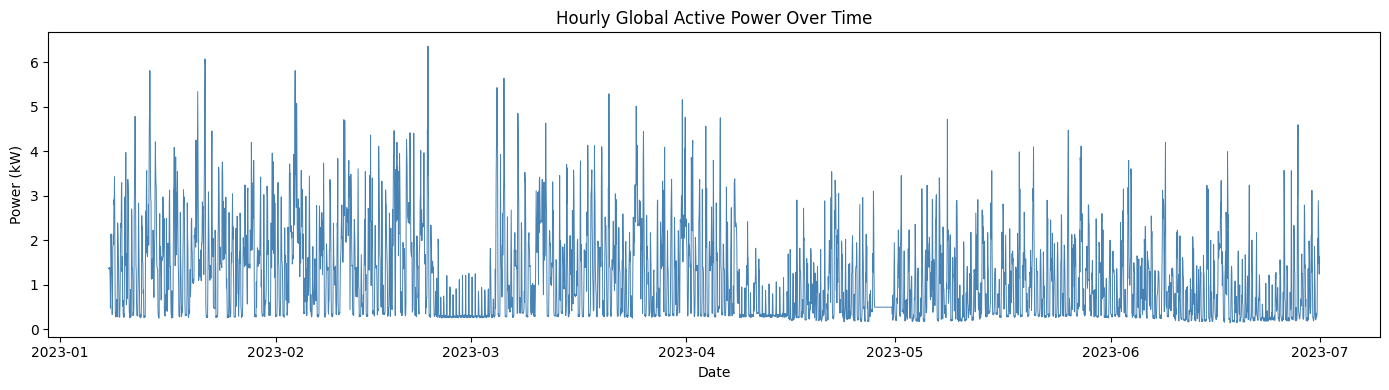

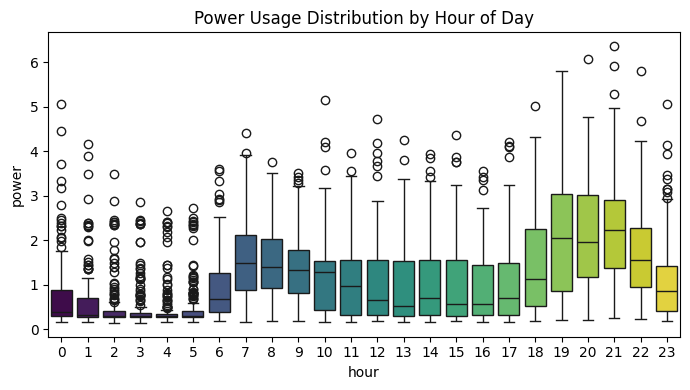

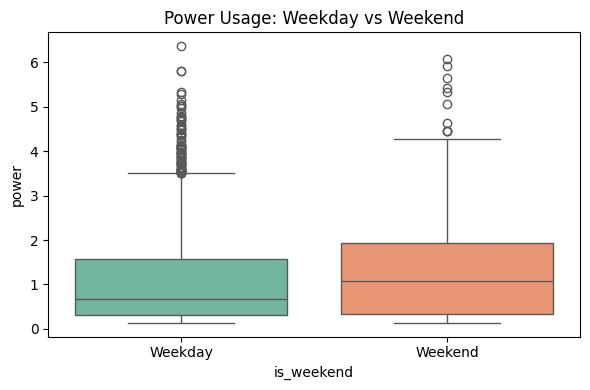

In [26]:
# 4. EDA PLOTS
plt.figure(figsize=(14, 4))
plt.plot(hourly.index, hourly["power"], color="steelblue", linewidth=0.7)
plt.title("Hourly Global Active Power Over Time")
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.tight_layout()
plt.savefig("eda_hourly_power_trend.png")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(x="hour", y="power", hue="hour", data=hourly, palette="viridis", legend=False)
plt.title("Power Usage Distribution by Hour of Day")
plt.tight_layout()
plt.savefig("eda_power_by_hour.png")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="is_weekend", y="power", hue="is_weekend", data=hourly, palette="Set2", legend=False)
plt.xticks([0, 1], ["Weekday", "Weekend"])
plt.title("Power Usage: Weekday vs Weekend")
plt.tight_layout()
plt.savefig("eda_power_weekday_weekend.png")
plt.show()

In [27]:
# 5. TRAIN / TEST SPLIT
horizon = 48   # forecast last 48 hours (2 days)
train = hourly.iloc[:-horizon]
test = hourly.iloc[-horizon:]

print(f"\nTrain size: {len(train)}, Test size: {len(test)}")

results = {}
metrics = {}


Train size: 4128, Test size: 48


In [28]:
# 6. MODEL 1 — ARIMA
print("\nTraining ARIMA...")
arima_model = ARIMA(train["power"], order=(2, 1, 2))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=horizon)
arima_forecast.index = test.index
results["ARIMA"] = arima_forecast



Training ARIMA...


In [29]:
# 7. MODEL 2 — PROPHET
print("Training Prophet...")
prophet_train = train.reset_index()[["datetime", "power"]].rename(
    columns={"datetime": "ds", "power": "y"}
)
prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=horizon, freq="h")
prophet_forecast_full = prophet_model.predict(future)
prophet_forecast = prophet_forecast_full.set_index("ds")["yhat"].iloc[-horizon:]
prophet_forecast.index = test.index
results["Prophet"] = prophet_forecast

Training Prophet...


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [30]:
# 8. MODEL 3 — XGBOOST
print("Training XGBoost...")
feature_cols = ["hour", "day_of_week", "is_weekend", "month", "day",
                 "lag_1", "lag_24", "lag_168", "rolling_mean_24"]

X_train, y_train = train[feature_cols], train["power"]
X_test, y_test = test[feature_cols], test["power"]

xgb_model = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_forecast = pd.Series(xgb_model.predict(X_test), index=test.index)
results["XGBoost"] = xgb_forecast

Training XGBoost...


In [31]:
# 9. EVALUATE MODELS
actual = test["power"]
for name, forecast in results.items():
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    metrics[name] = {"MAE": mae, "RMSE": rmse}

metrics_df = pd.DataFrame(metrics).T
print("\nModel comparison (lower is better):\n", metrics_df.round(4))
metrics_df.to_csv("model_comparison_metrics.csv")


Model comparison (lower is better):
             MAE    RMSE
ARIMA    0.6683  0.7820
Prophet  0.5021  0.6456
XGBoost  0.3751  0.5262


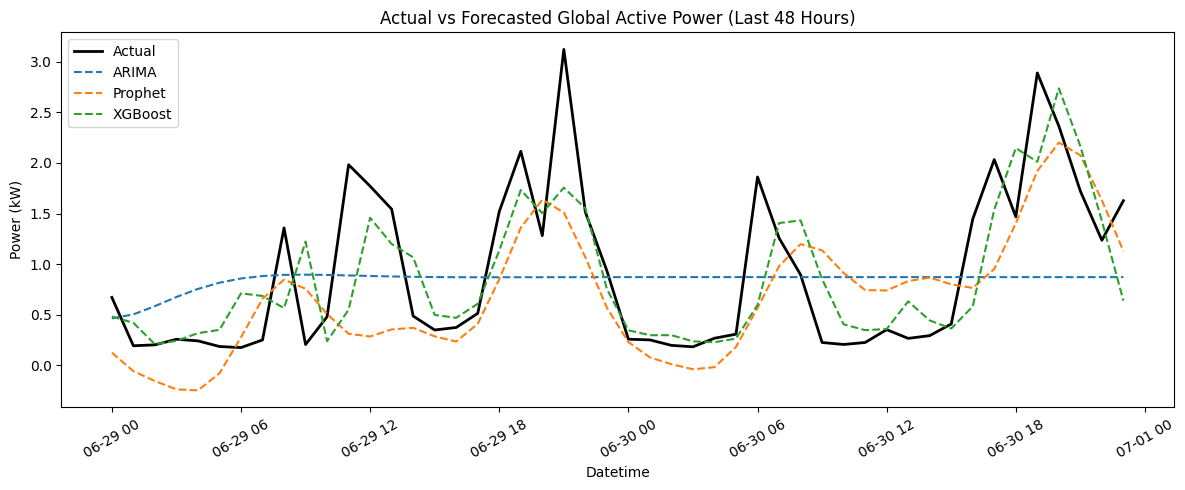

In [33]:
# 10. PLOT ACTUAL VS FORECASTED (ALL MODELS)
plt.figure(figsize=(12, 5))
plt.plot(actual.index, actual.values, label="Actual", color="black", linewidth=2)
plt.plot(results["ARIMA"].index, results["ARIMA"].values, label="ARIMA", linestyle="--")
plt.plot(results["Prophet"].index, results["Prophet"].values, label="Prophet", linestyle="--")
plt.plot(results["XGBoost"].index, results["XGBoost"].values, label="XGBoost", linestyle="--")
plt.title(f"Actual vs Forecasted Global Active Power (Last {horizon} Hours)")
plt.xlabel("Datetime")
plt.ylabel("Power (kW)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("actual_vs_forecast_comparison.png")
plt.show()

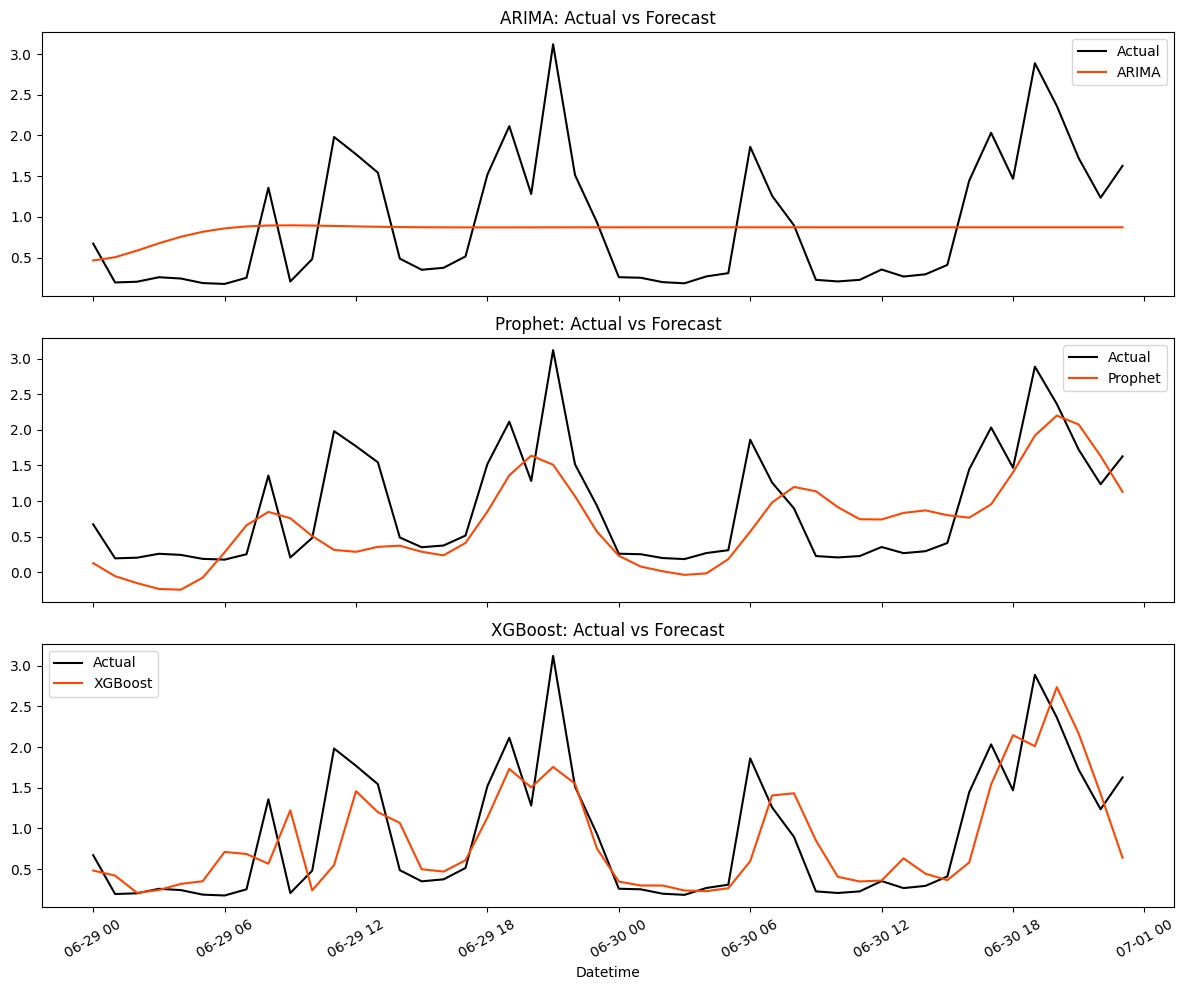

In [34]:
# Individual subplots per model for clarity
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, (name, forecast) in zip(axes, results.items()):
    ax.plot(actual.index, actual.values, label="Actual", color="black")
    ax.plot(forecast.index, forecast.values, label=name, color="orangered")
    ax.set_title(f"{name}: Actual vs Forecast")
    ax.legend()
plt.xlabel("Datetime")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("actual_vs_forecast_per_model.png")
plt.show()

In [37]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

metrics = {}
for name, forecast in results.items():
    metrics[name] = {
        "MAE": mean_absolute_error(actual, forecast),
        "RMSE": np.sqrt(mean_squared_error(actual, forecast)),
        "MAPE (%)": mape(actual, forecast)
    }

metrics_df = pd.DataFrame(metrics).T.round(4)
print(metrics_df)

best_model = metrics_df["RMSE"].idxmin()
print(f"\nBest model: {best_model}")

            MAE    RMSE  MAPE (%)
ARIMA    0.6683  0.7820  138.7830
Prophet  0.5021  0.6456   91.4886
XGBoost  0.3751  0.5262   62.3691

Best model: XGBoost


In [36]:
best_model = metrics_df["RMSE"].idxmin()
print(f"\nBest performing model based on RMSE: {best_model}")



Best performing model based on RMSE: XGBoost


***OBSERVATIONS:***

1- ARIMA: Good for short, stable series with clear autocorrelation,
But struggles with multiple seasonalities and external features.

2- Prophet: Handles daily/weekly seasonality and holidays well, easy to tune, good for interpretable trend + seasonality breakdown.

3- XGBoost: Best when lag/rolling features and external variables matter.Usually most accurate but needs more feature engineering and retraining.